Saved plot to: learning_curve_comparison.png


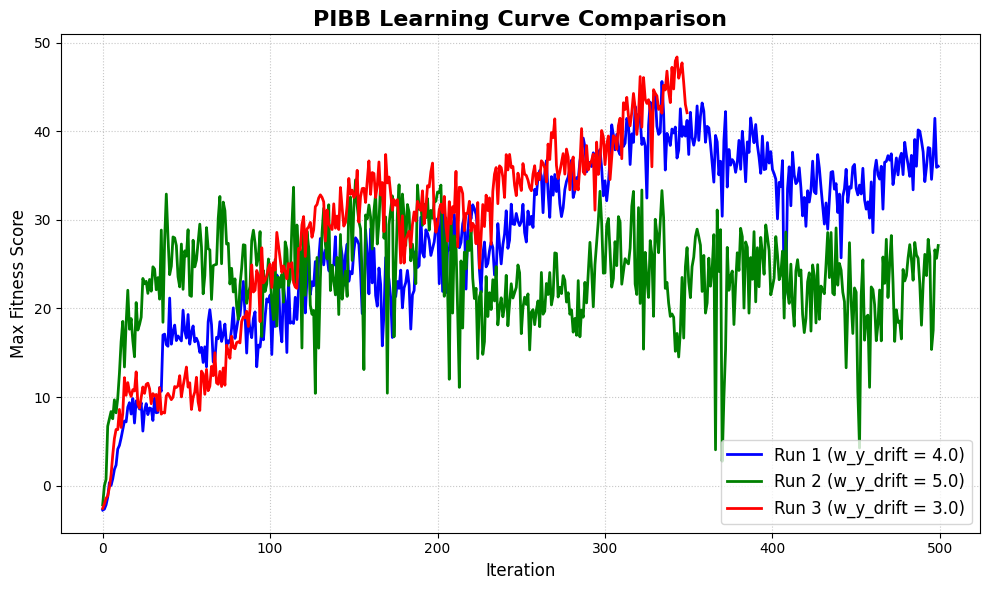

In [6]:
import json
import os
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURATION
# ==========================================
# List the three specific files you want to compare
TARGET_LOG_FILES = [
    "data/pibb_logs/pibb_training_20260710_212046.json", 
    "data/pibb_logs/pibb_training_20260710_234228.json",           
    "data/pibb_logs/pibb_training_20260710_181135.json"           
]

# Custom labels for the legend so you know which is which
LABELS = ["Run 1 (w_y_drift = 4.0)", "Run 2 (w_y_drift = 5.0)", "Run 3 (w_y_drift = 3.0)"]
COLORS = ["blue", "green", "red"]

def plot_static_comparison():
    fig, ax = plt.subplots(figsize=(10, 6))
    
    files_plotted = 0

    # Loop through each file and plot it
    for idx, file_path in enumerate(TARGET_LOG_FILES):
        if not os.path.exists(file_path):
            print(f"Warning: Could not find file {file_path}")
            continue

        # Read the JSON file
        with open(file_path, 'r') as f:
            log_data = json.load(f)

        # Extract the data arrays
        iterations = []
        max_fitness = []
        
        for entry in log_data:
            iterations.append(entry["iteration"])
            # Based on your logger structure:
            metrics = entry["metrics"]
            max_fitness.append(metrics["max_fitness"])
            
        # Plot Max fitness for this specific file
        label_name = LABELS[idx] if idx < len(LABELS) else f"Run {idx+1}"
        color_name = COLORS[idx] if idx < len(COLORS) else None
        
        ax.plot(iterations, max_fitness, label=label_name, color=color_name, linewidth=2)
        files_plotted += 1
    
    if files_plotted == 0:
        print("Error: No files were found to plot. Check your file paths!")
        return

    # Format the plot
    ax.set_title('PIBB Learning Curve Comparison', fontsize=16, fontweight='bold')
    ax.set_xlabel('Iteration', fontsize=12)
    ax.set_ylabel('Max Fitness Score', fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.7)
    
    # Add legend
    ax.legend(fontsize=12, loc='lower right')
    
    # Save the plot
    save_path = "learning_curve_comparison.png"
    plt.savefig(save_path, dpi=300)
    print(f"Saved plot to: {save_path}")
    
    # Show the plot
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_static_comparison()